# Medical Cost Predictor - Classification Project
**AI/ML Build Week - Day 7 Assignment**

Predicts whether a person's medical insurance charges are **high cost** (above median) or **low cost**.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


## 2. Load & Explore the Data

In [2]:
df = pd.read_csv('insurance.csv')
print('Shape:', df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### 2.1 Visualisation — Distribution of Charges

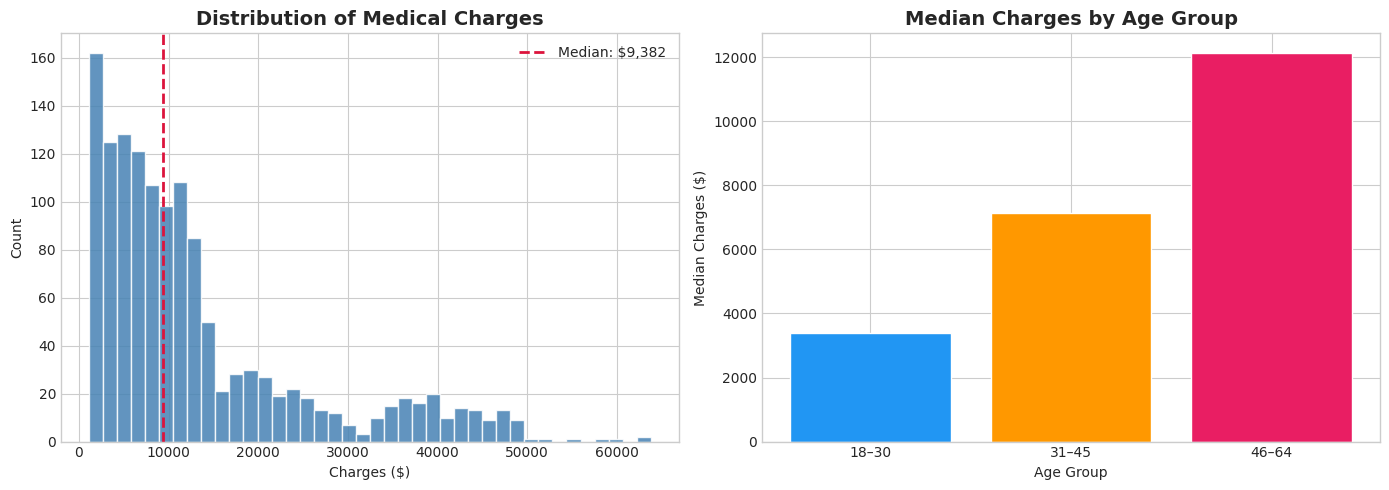

Plot saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of charges
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
median_val = df['charges'].median()
axes[0].axvline(median_val, color='crimson', linestyle='--', linewidth=2, label=f'Median: ${median_val:,.0f}')
axes[0].set_title('Distribution of Medical Charges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Charges by age group
df['age_group'] = pd.cut(df['age'], bins=[17,30,45,65], labels=['18–30','31–45','46–64'])
age_median = df.groupby('age_group')['charges'].median()
axes[1].bar(age_median.index, age_median.values, color=['#2196F3','#FF9800','#E91E63'], edgecolor='white')
axes[1].set_title('Median Charges by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Median Charges ($)')

plt.tight_layout()
plt.savefig('plot_charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

### 2.2 Visualisation — Smoker vs High Cost

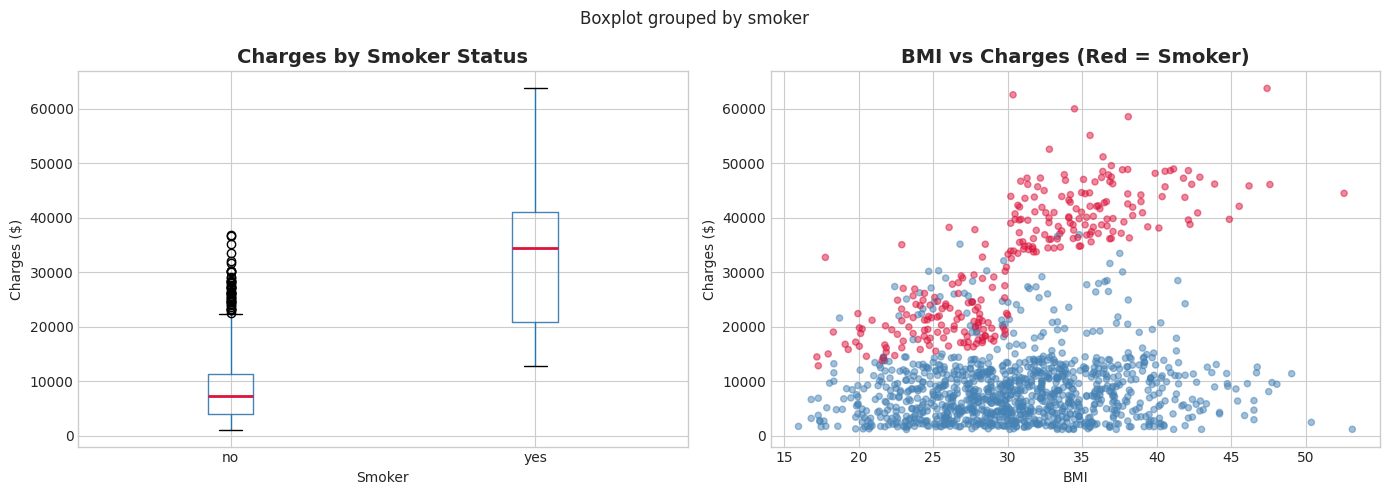

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: Smoker vs Charges
df.boxplot(column='charges', by='smoker', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='crimson', linewidth=2))
axes[0].set_title('Charges by Smoker Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges ($)')
plt.sca(axes[0])
plt.title('Charges by Smoker Status', fontsize=14, fontweight='bold')

# BMI vs Charges scatter
colors = df['smoker'].map({'yes': 'crimson', 'no': 'steelblue'})
axes[1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=20)
axes[1].set_title('BMI vs Charges (Red = Smoker)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.savefig('plot_smoker_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 3. Preprocess the Data

In [8]:
# Work on a clean copy
df_model = df.drop(columns=['age_group'], errors='ignore').copy()

# Binary encode sex and smoker
df_model['sex']    = df_model['sex'].map({'male': 1, 'female': 0})
df_model['smoker'] = df_model['smoker'].map({'yes': 1, 'no': 0})

# One-hot encode region (drop first to avoid multicollinearity)
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

# Create binary target: high_cost = 1 if charges > median
median_charges = df_model['charges'].median()
df_model['high_cost'] = (df_model['charges'] > median_charges).astype(int)

print(f'Median charges: ${median_charges:,.2f}')
print(f'High cost distribution:\n{df_model["high_cost"].value_counts()}')
df_model.head()

Median charges: $9,382.03
High cost distribution:
high_cost
1    669
0    669
Name: count, dtype: int64


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,high_cost
0,19,0,27.900,0,1,16884.92400,False,False,True,1
1,18,1,33.770,1,0,1725.55230,False,True,False,0
2,28,1,33.000,3,0,4449.46200,False,True,False,0
3,33,1,22.705,0,0,21984.47061,True,False,False,1
4,32,1,28.880,0,0,3866.85520,True,False,False,0


In [9]:
# Define features and target
X = df_model.drop(columns=['charges', 'high_cost'])
y = df_model['high_cost']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Feature columns:', list(X.columns))
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
Train size: 1070 | Test size: 268


## 4. Train & Evaluate Models

In [10]:
def evaluate_model(name, model, X_test, y_test):
    """Print metrics and return a results dict."""
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}  (high-cost class)')
    print(f'  Recall   : {rec:.4f}  (high-cost class)')
    print(f'  F1-Score : {f1:.4f}  (high-cost class)')
    print(f'\n{classification_report(y_test, y_pred, target_names=["Low Cost","High Cost"])}')

    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Cost','High Cost'],
                yticklabels=['Low Cost','High Cost'])
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    safe_name = name.lower().replace(' ','_').replace('(','').replace(')','').replace('=','')
    plt.savefig(f'cm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

### 4.1 Logistic Regression


  Logistic Regression
  Accuracy : 0.8993
  Precision: 0.8849  (high-cost class)
  Recall   : 0.9179  (high-cost class)
  F1-Score : 0.9011  (high-cost class)

              precision    recall  f1-score   support

    Low Cost       0.91      0.88      0.90       134
   High Cost       0.88      0.92      0.90       134

    accuracy                           0.90       268
   macro avg       0.90      0.90      0.90       268
weighted avg       0.90      0.90      0.90       268



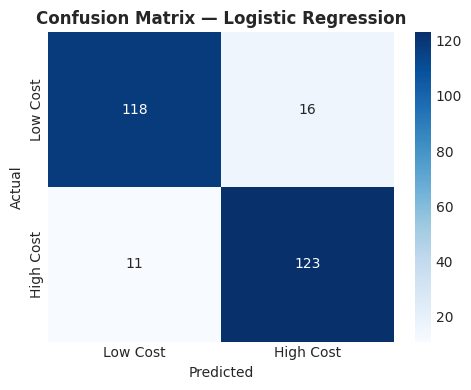

In [11]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_results = evaluate_model('Logistic Regression', lr_model, X_test, y_test)

### 4.2 Decision Tree — Default


  Decision Tree (Default)
  Accuracy : 0.8806
  Precision: 0.8806  (high-cost class)
  Recall   : 0.8806  (high-cost class)
  F1-Score : 0.8806  (high-cost class)

              precision    recall  f1-score   support

    Low Cost       0.88      0.88      0.88       134
   High Cost       0.88      0.88      0.88       134

    accuracy                           0.88       268
   macro avg       0.88      0.88      0.88       268
weighted avg       0.88      0.88      0.88       268



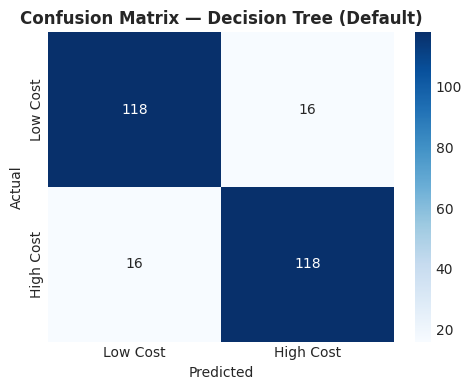

In [12]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)
dt_default_results = evaluate_model('Decision Tree (Default)', dt_default, X_test, y_test)

### 4.3 Decision Tree — Pruned (max_depth=4)


  Decision Tree (max_depth=4)
  Accuracy : 0.9328
  Precision: 0.9677  (high-cost class)
  Recall   : 0.8955  (high-cost class)
  F1-Score : 0.9302  (high-cost class)

              precision    recall  f1-score   support

    Low Cost       0.90      0.97      0.94       134
   High Cost       0.97      0.90      0.93       134

    accuracy                           0.93       268
   macro avg       0.94      0.93      0.93       268
weighted avg       0.94      0.93      0.93       268



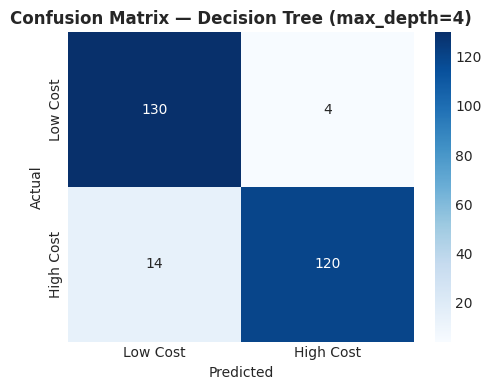

In [13]:
dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pruned.fit(X_train, y_train)
dt_pruned_results = evaluate_model('Decision Tree (max_depth=4)', dt_pruned, X_test, y_test)

## 5. Compare Models

                             accuracy  precision  recall      f1
name                                                            
Logistic Regression            0.8993     0.8849  0.9179  0.9011
Decision Tree (Default)        0.8806     0.8806  0.8806  0.8806
Decision Tree (max_depth=4)    0.9328     0.9677  0.8955  0.9302


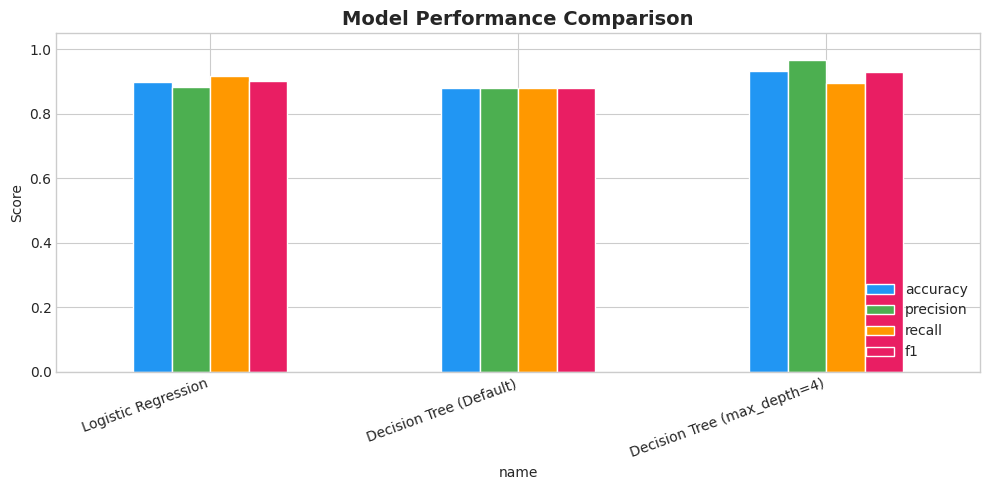

In [14]:
results_df = pd.DataFrame([lr_results, dt_default_results, dt_pruned_results])
results_df = results_df.set_index('name')
print(results_df.round(4))

# Bar chart comparison
results_df[['accuracy','precision','recall','f1']].plot(
    kind='bar', figsize=(10, 5), edgecolor='white',
    color=['#2196F3','#4CAF50','#FF9800','#E91E63']
)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Pick best model by recall (most important for high-cost patients)
best_name = results_df['recall'].idxmax()
best_score = results_df.loc[best_name, 'recall']
print(f'\nBest model by recall: {best_name} (recall = {best_score:.4f})')
print('\nRationale: For medical cost prediction, high recall means we catch more true'
      ' high-cost patients, minimising costly false negatives for insurers.')


Best model by recall: Logistic Regression (recall = 0.9179)

Rationale: For medical cost prediction, high recall means we catch more true high-cost patients, minimising costly false negatives for insurers.


## 6. Save the Best Model

In [16]:
model_map = {
    'Logistic Regression':           lr_model,
    'Decision Tree (Default)':       dt_default,
    'Decision Tree (max_depth=4)':   dt_pruned,
}

best_model = model_map[best_name]

# Save model and feature columns together
model_artifact = {
    'model':    best_model,
    'features': list(X.columns),
    'median_charges': median_charges
}

joblib.dump(model_artifact, 'best_model.pkl')
print(f'Saved best model ({best_name}) to best_model.pkl')

Saved best model (Logistic Regression) to best_model.pkl


## 7. Quick Model Test

In [17]:
# Verify the saved model loads and predicts correctly
loaded = joblib.load('best_model.pkl')
test_row = X_test.iloc[[0]]
pred  = loaded['model'].predict(test_row)[0]
proba = loaded['model'].predict_proba(test_row)[0][1]
label = 'High Cost' if pred == 1 else 'Low Cost'
print(f'Sample prediction: {label}  (probability of high cost = {proba:.2%})')
print('\nModel loaded and working correctly!')

Sample prediction: High Cost  (probability of high cost = 96.31%)

Model loaded and working correctly!
